<a href="https://colab.research.google.com/github/EhsanNikpey/Mole-Risk-Classification/blob/main/mole_detection_image_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [370]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [373]:
from skimage.measure import label, regionprops, perimeter
import matplotlib.image as mpimg
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
filein = '/content/drive/MyDrive/health sources/lab2_moles/train/high/melanoma_3.jpg'
data = mpimg.imread (filein)

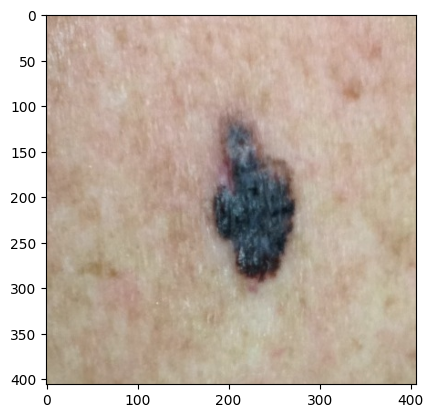

In [374]:
plt.imshow(data)
plt.axis()
plt.show()  # See the image

# New Section

In [375]:
rows , columns , depth = data.shape # Define row, column and depth

In [376]:
data = data.reshape(rows*columns,3)  # Reshape the 3D Ndarray into a 2D Ndarray
# (K-means algorithm does not take into consideration the order of the data)

In [377]:
data.shape  # Shape of data after reshape

(164836, 3)

In [378]:
print(data[:10])

[[196 167 151]
 [199 170 154]
 [177 148 132]
 [175 146 130]
 [181 152 134]
 [175 146 128]
 [180 151 133]
 [178 149 131]
 [173 144 126]
 [176 147 129]]


In [379]:
kmeans = KMeans(n_clusters=3,random_state=0)  # Instantiate the K-means object
kmeans.fit(data)  # To find the clusters

KMeans(n_clusters=3, random_state=0)

In [380]:
kmeans.cluster_centers_  # This returns the coordinates of the cluster centroids
kmeans.labels_   # This provides the labels for each data point
Ncluster= len( kmeans.cluster_centers_)   # This calculates the number of clusters in the K-Means model by counting the number of cluster centers

In [381]:
centroids = kmeans.cluster_centers_.astype ('uint8')  # Change centroids from float numbers to uint8 numbers

In [382]:
print(centroids)  # These three centroids represent the three colors that K-means found as representatives of all the image colors

[[199 179 163]
 [ 64  69  77]
 [177 156 138]]


In [383]:
im_2D_quant = data.copy()   # This code performs image quantization using K-Means clustering
for kc in range (Ncluster):  # Reduces the number of unique colors by assigning centroid's color to all pixels in the same cluster
  im_2D_quant[(kmeans.labels_ == kc),:]= centroids [kc,:]
im_quant = im_2D_quant.reshape ((rows,columns,depth))

In [384]:
im_quant.shape

(406, 406, 3)

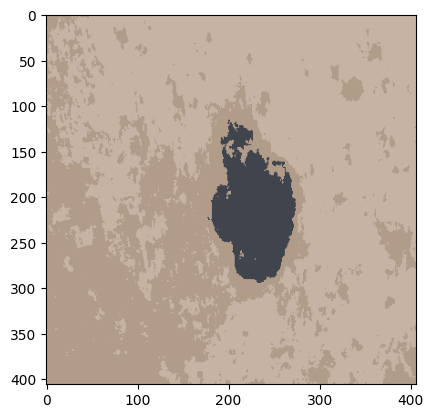

In [385]:
plt.imshow(im_quant)  # Quantize image to only have 3 colors

In [386]:
centroids = kmeans.cluster_centers_  # Extracts the cluster centroids calculated by the K-Means algorithm
conv_to_gray = np.array ([0.2125 ,0.7154 ,0.0721])  # Defines weights for converting RGB colors to grayscale
centroids_gray = centroids@conv_to_gray  # Converts the RGB centroids into grayscale values by using the conv_to_gray weights.
i_col = centroids_gray.argmin ()   # Finds the index of the centroid with the smallest grayscale value for finding darkest color.

In [387]:
im_clust = kmeans.labels_.reshape(rows,columns)
mole_pos = np.argwhere(im_clust == i_col)  # find the positions of the pixels belonging to cluster i_col (position of the mole)

In [388]:
print(mole_pos)  #pixels position that has darker colors

[[116 200]
 [116 201]
 [117 200]
 ...
 [294 233]
 [294 234]
 [294 235]]


In [389]:
clusters = DBSCAN(eps=2,min_samples=10).fit(mole_pos)  # Use DBSCAN to find mole position and detect outliers

In [390]:
print(clusters.labels_)

[-1 -1 -1 ...  1  1  1]


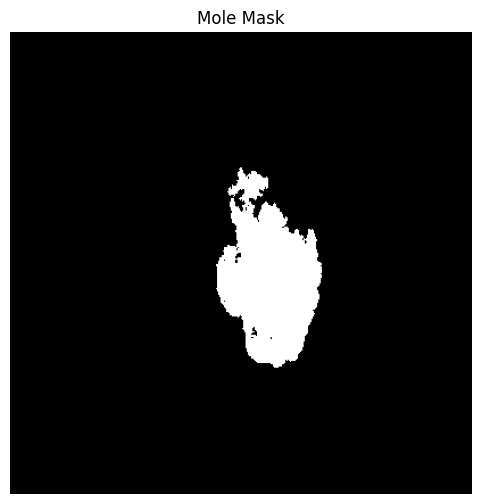

In [391]:
labels = clusters.labels_

valid_labels = labels[labels != -1]

if len(valid_labels) == 0:
    raise ValueError("DBSCAN found no valid clusters.")

largest_cluster = max(
    set(valid_labels),
    key=lambda l: np.sum(labels == l)
)

true_mole_pos = mole_pos[labels == largest_cluster]

im = data.reshape(rows, columns, 3)

# Use float image so missing pixels can be NaN
im_only_mole = np.full_like(im, np.nan, dtype=float)

x = true_mole_pos[:, 0]
y = true_mole_pos[:, 1]

im_only_mole[x, y] = im[x, y]


im_mole_pos = np.zeros((rows, columns))
im_mole_pos[x, y] = 1

plt.figure(figsize=(6, 6))
plt.imshow(im_mole_pos, cmap="gray", interpolation=None)
plt.title("Mole Mask")
plt.axis("off")

plt.show()

In [392]:
delta = 5  # Define the size of the neighborhood around each pixel for filtering
im_mole_pos_red_filt = 0 * im_mole_pos  # Initialize a blank image of the same size as the binary mask
# Iterate over each pixel, excluding the borders
for kr in range(delta, rows - delta):  # Loop over rows, leaving a margin of 'delta' pixels
  for kc in range(delta, columns - delta):  # Loop over columns, leaving a margin of 'delta' pixels
    sub = im_mole_pos[kr - delta:kr + delta, kc - delta:kc + delta]  # Extract a local region of size 2*delta x 2*delta around the current pixel
    im_mole_pos_red_filt[kr, kc] = np.median(sub)  # Assign the median value of the subarray to the current pixel in the filtered image

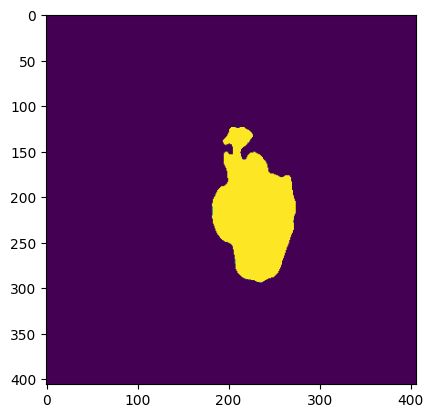

In [393]:
plt.imshow(im_mole_pos_red_filt)

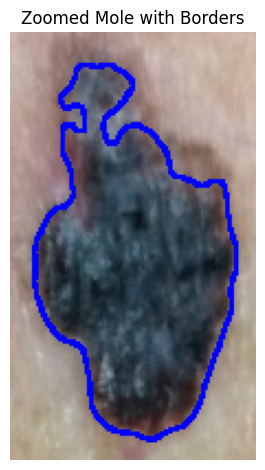

In [394]:
from scipy.signal import convolve2d

# Define Sobel filters for detecting edges in the x and y directions
H_x = np.array([[1, 0, -1],
                [2, 0, -2],
                [1, 0, -1]])

H_y = np.array([[1, 2, 1],
                [0, 0, 0],
                [-1, -2, -1]])

# Apply the Sobel filter in the x-direction and y-direction to the reduced filtered image
edges_x = convolve2d(im_mole_pos_red_filt, H_x, mode='same', boundary='fill', fillvalue=0)
edges_y = convolve2d(im_mole_pos_red_filt, H_y, mode='same', boundary='fill', fillvalue=0)

# Compute the magnitude of the gradients to combine x and y edge information
edges = np.sqrt(edges_x**2 + edges_y**2)

# Set a threshold to convert the gradient magnitudes to a binary edge map
threshold = 0.1 * np.max(edges)  # Use 10% of the maximum edge magnitude as the threshold
edges_binary = edges > threshold  # Create a binary image where edges are marked as True

overlay = im.copy() # Create a copy of the original image to overlay the edges

# Set the edges in the overlay to blue (RGB: [0, 0, 255])
overlay[edges_binary] = [0, 0, 255]  # Blue color for the edges

# Calculate the minimum and maximum x-coordinates of the mole
x_min, x_max = true_mole_pos[:, 0].min(), true_mole_pos[:, 0].max()

# Calculate the minimum and maximum y-coordinates of the mole
y_min, y_max = true_mole_pos[:, 1].min(), true_mole_pos[:, 1].max()

# Add some padding to the bounding box to include some surrounding area of the mole
padding = 10
x_min = max(x_min - padding, 0)  # Ensure x_min does not go below 0
x_max = min(x_max + padding, rows)  # Ensure x_max does not exceed the image rows
y_min = max(y_min - padding, 0)  # Ensure y_min does not go below 0
y_max = min(y_max + padding, columns)  # Ensure y_max does not exceed the image columns

# Crop the region around the mole from the overlayed image
zoomed_mole = overlay[x_min:x_max, y_min:y_max]

# Plot the zoomed-in region of the mole with the borders
plt.subplot(1, 2, 2)
plt.imshow(zoomed_mole.astype('uint8'))
plt.title("Zoomed Mole with Borders")
plt.axis('off')
plt.tight_layout()
plt.show()


To extract relevant features from the isolated mole according to the **ABCDE rule**, we consider the following steps for each feature:

### 1. **A - Asymmetry**
   - **Feature**: Determine whether one half of the mole is different from the other.

### 2. **B - Border**
   - **Feature**: Assess if the border is irregular, notched, or uneven.

### 3. **C - Color**
   - **Feature**: Identify uneven color distribution or multiple colors within the mole.

### 4. **D - Diameter**
   - **Feature**: Measure the size of the mole and check if it is larger than a threshold.

### 5. **E - Evolution**
   - **Feature**: Track changes in size, shape, or color over time.

# Classification Part

In [359]:
import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import load_img, img_to_array


TRAIN_DIR = "/content/drive/MyDrive/health sources/lab2_moles/train"
TEST_DIR  = "/content/drive/MyDrive/health sources/lab2_moles/test"

train_dir = pathlib.Path(TRAIN_DIR)
test_dir = pathlib.Path(TEST_DIR)

img_height = 224
img_width = 224
batch_size = 32
epochs = 20

In [360]:
expected_folders = ["low", "medium", "high"]

print("Checking training folders:")

for folder_name in expected_folders:
    folder_path = train_dir / folder_name
    images = list(folder_path.glob("*"))

    print(f"{folder_name}: {len(images)} image(s)")

    if len(images) == 0:
        print(f"WARNING: {folder_name} folder is empty!")

Checking training folders:
low: 10 image(s)
medium: 13 image(s)
high: 20 image(s)


In [361]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("\nTensorFlow detected class order:")
print(class_names)

Found 43 files belonging to 3 classes.
Using 35 files for training.
Found 43 files belonging to 3 classes.
Using 8 files for validation.

TensorFlow detected class order:
['high', 'low', 'medium']



Labels in one batch:
[0 1 0 1 1 1 1 0 2 1 0 2 0 1 0 2 2 2 0 0 2 2 0 1 0 0 0 0 0 0 2 2]


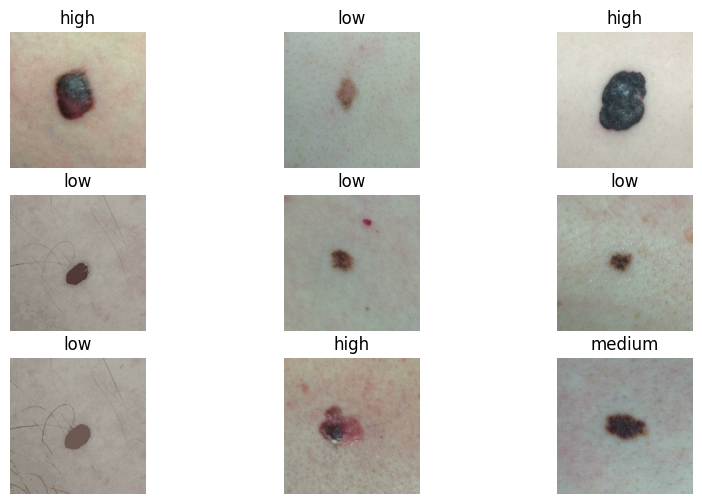

In [362]:
for images, labels in train_ds.take(1):
    print("\nLabels in one batch:")
    print(labels.numpy())

    plt.figure(figsize=(10, 6))
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.show()

In [363]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
])


In [364]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [365]:
model = keras.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Dropout(0.4),
    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes)
])

model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [366]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.2571 - loss: 1.8815 - val_accuracy: 0.3750 - val_loss: 3.3009
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 906ms/step - accuracy: 0.4857 - loss: 2.3702 - val_accuracy: 0.3750 - val_loss: 1.5662
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.1143 - loss: 1.9247 - val_accuracy: 0.3750 - val_loss: 1.1089
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 5s/step - accuracy: 0.4571 - loss: 1.0601 - val_accuracy: 0.3750 - val_loss: 1.0895
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.4857 - loss: 1.0253 - val_accuracy: 0.3750 - val_loss: 1.1125
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step - accuracy: 0.4857 - loss: 1.0134 - val_accuracy: 0.3750 - val_loss: 1.0795
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.4857 - loss: 1.0215 - val_accuracy: 0.3750 - val_loss: 1.0571
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 5s/step - accuracy: 0.5143 - loss: 1.0596 - val_accuracy: 0.3750 - val_loss: 1.0543
Epoch 9/20


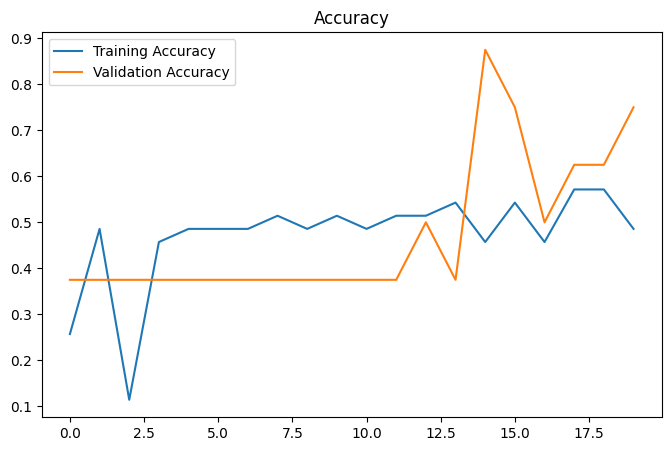

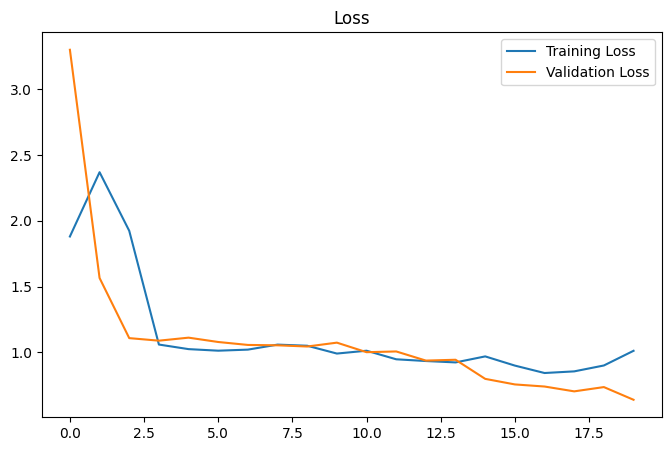

In [367]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Loss")
plt.show()

In [368]:
def predict_risk(image_path):
    img = load_img(image_path, target_size=(img_height, img_width))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)
    scores = tf.nn.softmax(predictions[0]).numpy()

    predicted_index = np.argmax(scores)
    predicted_class = class_names[predicted_index]
    confidence = scores[predicted_index] * 100

    print("\nImage:", os.path.basename(image_path))
    print("Class probabilities:")

    for name, score in zip(class_names, scores):
        print(f"{name}: {score * 100:.2f}%")

    print("Final prediction:", predicted_class)
    print("Confidence:", f"{confidence:.2f}%")

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{predicted_class} risk ({confidence:.2f}%)")
    plt.show()

    return predicted_class, confidence


Test images found: 15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step

Image: medium_risk_15.jpg
Class probabilities:
high: 98.03%
low: 0.53%
medium: 1.44%
Final prediction: high
Confidence: 98.03%


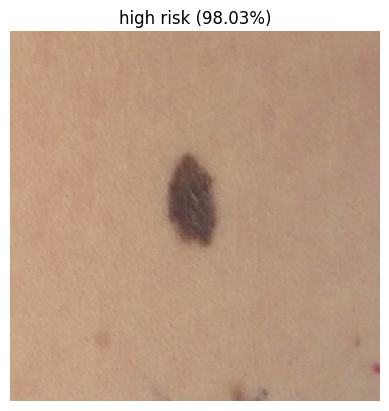

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step

Image: medium_risk_14.jpg
Class probabilities:
high: 43.73%
low: 22.25%
medium: 34.02%
Final prediction: high
Confidence: 43.73%


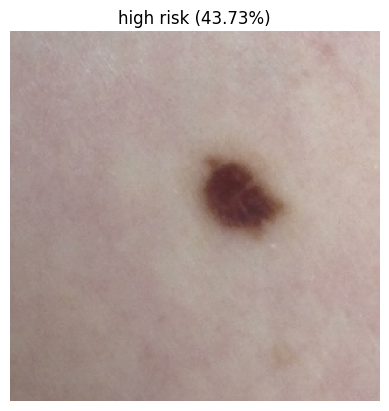

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

Image: medium_risk_13.jpg
Class probabilities:
high: 52.85%
low: 18.75%
medium: 28.40%
Final prediction: high
Confidence: 52.85%


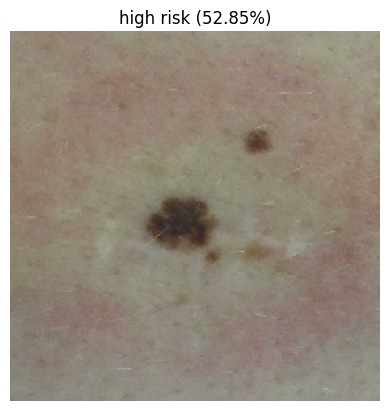

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step

Image: medium_risk_12.jpg
Class probabilities:
high: 22.76%
low: 38.93%
medium: 38.30%
Final prediction: low
Confidence: 38.93%


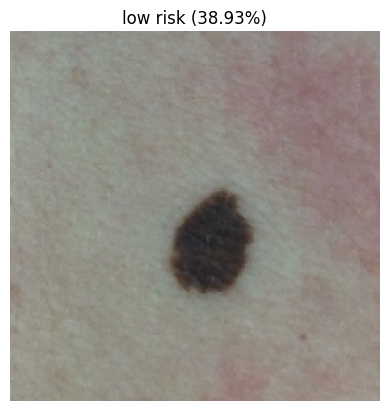

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step

Image: medium_risk_16.jpg
Class probabilities:
high: 32.52%
low: 26.12%
medium: 41.36%
Final prediction: medium
Confidence: 41.36%


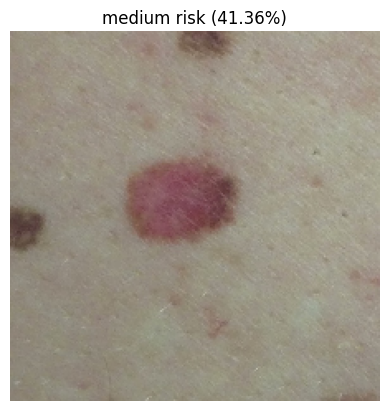

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

Image: melanoma_21.jpg
Class probabilities:
high: 98.31%
low: 0.42%
medium: 1.27%
Final prediction: high
Confidence: 98.31%


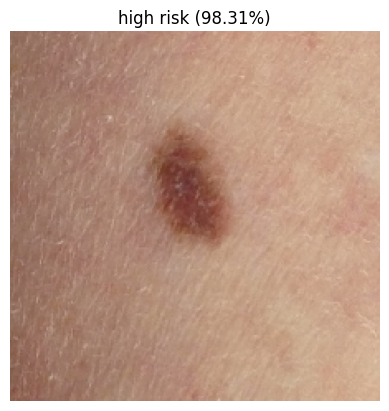

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step

Image: melanoma_27.jpg
Class probabilities:
high: 99.93%
low: 0.01%
medium: 0.06%
Final prediction: high
Confidence: 99.93%


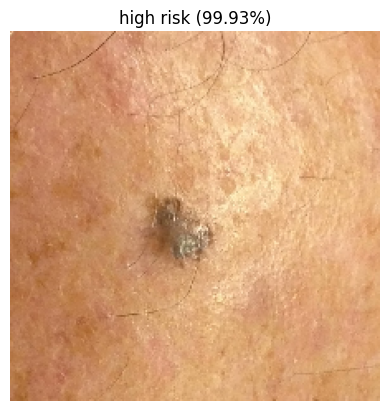

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step

Image: low_risk_11.jpg
Class probabilities:
high: 21.71%
low: 35.60%
medium: 42.69%
Final prediction: medium
Confidence: 42.69%


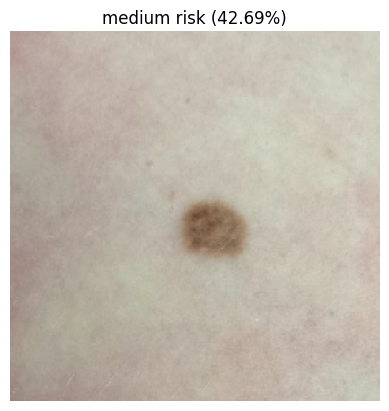

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step

Image: melanoma_23.jpg
Class probabilities:
high: 81.43%
low: 6.07%
medium: 12.50%
Final prediction: high
Confidence: 81.43%


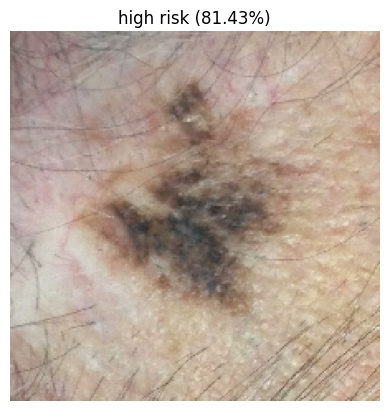

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step

Image: melanoma_26.jpg
Class probabilities:
high: 25.65%
low: 35.64%
medium: 38.72%
Final prediction: medium
Confidence: 38.72%


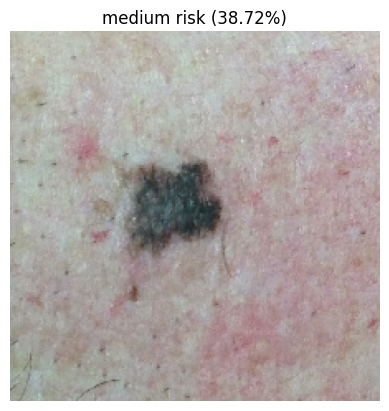

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step

Image: melanoma_25.jpg
Class probabilities:
high: 99.66%
low: 0.08%
medium: 0.26%
Final prediction: high
Confidence: 99.66%


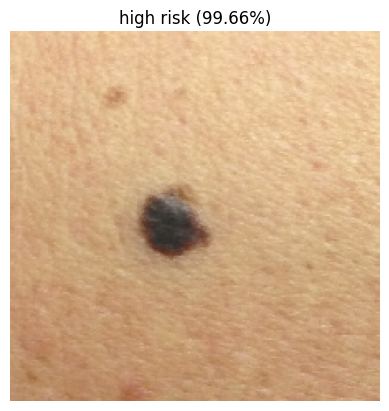

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step

Image: melanoma_24.jpg
Class probabilities:
high: 97.76%
low: 0.61%
medium: 1.63%
Final prediction: high
Confidence: 97.76%


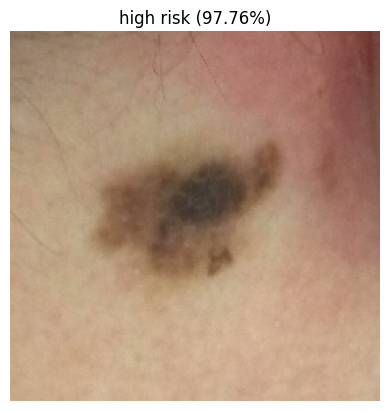

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step

Image: low_risk_9.jpg
Class probabilities:
high: 18.93%
low: 39.50%
medium: 41.58%
Final prediction: medium
Confidence: 41.58%


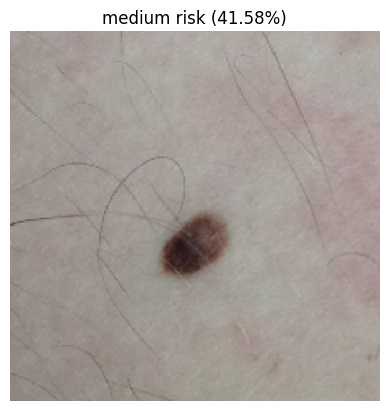

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

Image: melanoma_22.jpg
Class probabilities:
high: 23.68%
low: 34.39%
medium: 41.93%
Final prediction: medium
Confidence: 41.93%


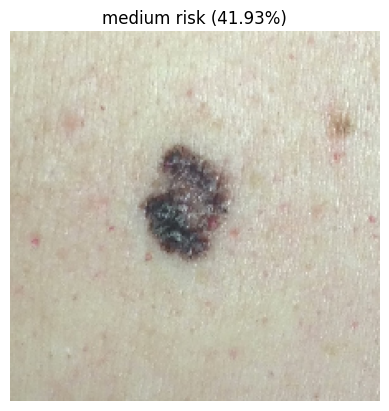

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step

Image: low_risk_10.jpg
Class probabilities:
high: 10.55%
low: 50.44%
medium: 39.00%
Final prediction: low
Confidence: 50.44%


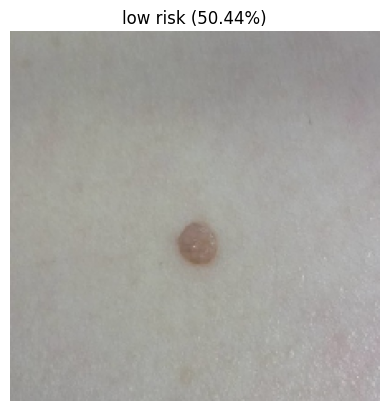

In [369]:
image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

test_images = [
    file for file in test_dir.glob("*")
    if file.suffix.lower() in image_extensions
]

print("\nTest images found:", len(test_images))

for image_path in test_images:
    predict_risk(str(image_path))

# Limitation of the Model

This mole risk classification model was trained using a relatively **small dataset** consisting of three categories: Low Risk, Medium Risk, and High Risk.

Machine learning and deep learning models generally require a large number of diverse training images to achieve high accuracy and reliable generalization. Due to the limited number of samples available in this project, the model may not always correctly classify unseen images and its performance may vary depending on image quality, lighting conditions, and lesion appearance.

The accuracy obtained in this project should therefore be interpreted with caution. Increasing the size and diversity of the dataset, balancing the number of images across categories, and incorporating additional training data would likely improve the model's performance.

Therefore, this model should be considered an educational and experimental prototype rather than a clinical diagnostic tool.